In [13]:
import requests
import zipfile
import io
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

In [14]:
ANNOTATION_URL = (
    "https://rndml-team-cv.obs.ru-moscow-1.hc.sbercloud.ru/"
    "datasets/hagrid_v2/annotations_with_landmarks/annotations.zip"
)

In [15]:
ANNOTATION_DIR = Path("/content/hagrid_annotations")

In [16]:
ANNOTATION_DIR.mkdir(parents = True , exist_ok = True)

In [17]:
print(ANNOTATION_DIR)

/content/hagrid_annotations


In [18]:
response = requests.get(ANNOTATION_URL,stream = True)

In [19]:
response.raise_for_status()
print(response.status_code)

200


In [20]:
zip_data = io.BytesIO(response.content)

In [21]:
with zipfile.ZipFile(zip_data, 'r') as zip_ref:
  zip_ref.extractall(ANNOTATION_DIR)


In [22]:
def find_split_directory(root, split_name):
  candidates = [
      p for p in root.rglob(split_name)
      if p.is_dir()
  ]
  if len(candidates) == 0:
    raise FileNotFoundError (
        f"Could not find 'split_name' directory"
    )
  for candidate in candidates:
    if any(candidate.glob("*.json")):
      return candidate

In [24]:
train_dir = find_split_directory(ANNOTATION_DIR, "train")
valid_dir = find_split_directory(ANNOTATION_DIR, "val")
test_dir = find_split_directory(ANNOTATION_DIR, 'test')
print("train_dir", train_dir)
print("valid_dir", valid_dir)
print("test_dir", test_dir)

train_dir /content/hagrid_annotations/annotations/train
valid_dir /content/hagrid_annotations/annotations/val
test_dir /content/hagrid_annotations/annotations/test


In [25]:
CLASSES = [
    "call",
    "dislike",
    "fist",
    "four",
    "grabbing",
    "grip",
    "hand_heart",
    "hand_heart2",
    "holy",
    "like",
    "little_finger",
    "middle_finger",
    "mute",
    "no_gesture",
    "ok",
    "one",
    "palm",
    "peace",
    "peace_inverted",
    "point",
    "rock",
    "stop",
    "stop_inverted",
    "take_picture",
    "three",
    "three2",
    "three3",
    "three_gun",
    "thumb_index",
    "thumb_index2",
    "timeout",
    "two_up",
    "two_up_inverted",
    "xsign"
]

In [26]:
print(len(CLASSES))

34


In [27]:
example_file = train_dir/ "call.json"
with open(example_file, 'r', encoding = 'utf-8') as f:
  example_data = json.load(f)

first_image_id = next(iter(example_data))

print("\nFirst image ID:")
print(first_image_id)

print("\nFirst annotation:")
print(json.dumps(
    example_data[first_image_id],
    indent=2
)[:3000])


First image ID:
fff0de6d-e13a-46fc-b4da-b6cc30b64193

First annotation:
{
  "bboxes": [
    [
      0.18734749,
      0.33293158,
      0.21059816,
      0.18203551
    ]
  ],
  "user_id": "58a00d5a0ca78ce21efa8bb262f17148238e405b935a915a15da91be8a2053ef",
  "labels": [
    "call"
  ],
  "united_bbox": null,
  "united_label": null,
  "meta": {
    "age": [
      16.79
    ],
    "gender": [
      "female"
    ],
    "race": [
      "White"
    ]
  },
  "hand_landmarks": [
    [
      [
        0.18971013781339766,
        0.4587335115000665
      ],
      [
        0.21096733177277088,
        0.42758556519249374
      ],
      [
        0.25389345521427314,
        0.3959862912409186
      ],
      [
        0.2877350086682642,
        0.3715907079627824
      ],
      [
        0.3049125989008888,
        0.34766953990694194
      ],
      [
        0.28167611817048316,
        0.40199066744462075
      ],
      [
        0.35239053912055496,
        0.41912197452507166
      ],
   

In [30]:
print(len(example_data))

20061


In [31]:
def count_images(json_file):
  with open(json_file, 'r', encoding = 'utf-8') as f:
    data = json.load(f)
  return len(data)


In [32]:
def get_class_count(split_dir, class_name):
  json_file = split_dir / f"{class_name}.json"
  if not json_file.exists():
    print("WARNING: Missing file {json_file}")
    return 0
  return count_images(json_file)

In [42]:
rows = []
for class_name in CLASSES:

    train_count = get_class_count(
        train_dir,
        class_name
    )

    val_count = get_class_count(
        valid_dir,
        class_name
    )

    test_count = get_class_count(
        test_dir,
        class_name
    )

    total_count = (
        train_count
        + val_count
        + test_count
    )

    rows.append({
        "Class": class_name,
        "Train_count": train_count,
        "Validation_count": val_count,
        "Test_count": test_count,
        "Total_count": total_count
    })


counts_df = pd.DataFrame(rows)

display(counts_df)

,Class,Train_count,Validation_count,Test_count,Total_count
0,call,20061,3000,5000,28061
1,dislike,23624,3000,5000,31624
2,fist,23543,3000,5000,31543
3,four,23436,3000,5000,31436
4,grabbing,28352,3000,5000,36352
5,grip,28406,3000,5000,36406
6,hand_heart,21576,3000,5000,29576
7,hand_heart2,23986,3000,5000,31986
8,holy,31402,3000,5000,39402
9,like,23244,3000,5000,31244


In [43]:
# ============================================================
# VERIFY DATASET TOTALS
# ============================================================

train_total = counts_df["Train_count"].sum()
val_total = counts_df["Validation_count"].sum()
test_total = counts_df["Test_count"].sum()
grand_total = counts_df["Total_count"].sum()

print("=" * 60)
print("HAGRIDv2 DATASET TOTALS")
print("=" * 60)

print(f"Train      : {train_total:,}")
print(f"Validation : {val_total:,}")
print(f"Test       : {test_total:,}")
print(f"Total      : {grand_total:,}")

print("\nOfficial HaGRIDv2 totals:")
print("Train      : 821,458")
print("Validation : 99,200")
print("Test       : 165,500")
print("Total      : 1,086,158")

print("\nVerification:")

print(
    "Train:",
    "PASS" if train_total == 821458 else "CHECK"
)

print(
    "Validation:",
    "PASS" if val_total == 99200 else "CHECK"
)

print(
    "Test:",
    "PASS" if test_total == 165500 else "CHECK"
)

print(
    "Total:",
    "PASS" if grand_total == 1086158 else "CHECK"
)

HAGRIDv2 DATASET TOTALS
Train      : 821,458
Validation : 99,200
Test       : 165,500
Total      : 1,086,158

Official HaGRIDv2 totals:
Train      : 821,458
Validation : 99,200
Test       : 165,500
Total      : 1,086,158

Verification:
Train: PASS
Validation: PASS
Test: PASS
Total: PASS


In [45]:
# ============================================================
# CALCULATE PERCENTAGES
# ============================================================

TRAIN_TOTAL = train_total
VAL_TOTAL = val_total
TEST_TOTAL = test_total
GRAND_TOTAL = grand_total


counts_df["Train_pct"] = (
    counts_df["Train_count"]
    / TRAIN_TOTAL
    * 100
)

counts_df["Validation_pct"] = (
    counts_df["Validation_count"]
    / VAL_TOTAL
    * 100
)

counts_df["Test_pct"] = (
    counts_df["Test_count"]
    / TEST_TOTAL
    * 100
)

counts_df["Total_pct"] = (
    counts_df["Total_count"]
    / GRAND_TOTAL
    * 100
)

In [46]:
# ============================================================
# FORMAT FINAL TABLE
# ============================================================

result_df = pd.DataFrame()

result_df["Class"] = counts_df["Class"]

result_df["Train"] = counts_df.apply(
    lambda row:
        f"{row['Train_count']:,} "
        f"({row['Train_pct']:.2f}%)",
    axis=1
)

result_df["Validation"] = counts_df.apply(
    lambda row:
        f"{row['Validation_count']:,} "
        f"({row['Validation_pct']:.2f}%)",
    axis=1
)

result_df["Test"] = counts_df.apply(
    lambda row:
        f"{row['Test_count']:,} "
        f"({row['Test_pct']:.2f}%)",
    axis=1
)

result_df["Total"] = counts_df.apply(
    lambda row:
        f"{row['Total_count']:,} "
        f"({row['Total_pct']:.2f}%)",
    axis=1
)


# ============================================================
# ADD TOTAL ROW
# ============================================================

total_row = pd.DataFrame([{
    "Class": "TOTAL",
    "Train": f"{TRAIN_TOTAL:,} (100.00%)",
    "Validation": f"{VAL_TOTAL:,} (100.00%)",
    "Test": f"{TEST_TOTAL:,} (100.00%)",
    "Total": f"{GRAND_TOTAL:,} (100.00%)"
}])


result_df = pd.concat(
    [result_df, total_row],
    ignore_index=True
)


# ============================================================
# DISPLAY
# ============================================================

display(result_df)

,Class,Train,Validation,Test,Total
0,call,"20,061 (2.44%)","3,000 (3.02%)","5,000 (3.02%)","28,061 (2.58%)"
1,dislike,"23,624 (2.88%)","3,000 (3.02%)","5,000 (3.02%)","31,624 (2.91%)"
2,fist,"23,543 (2.87%)","3,000 (3.02%)","5,000 (3.02%)","31,543 (2.90%)"
3,four,"23,436 (2.85%)","3,000 (3.02%)","5,000 (3.02%)","31,436 (2.89%)"
4,grabbing,"28,352 (3.45%)","3,000 (3.02%)","5,000 (3.02%)","36,352 (3.35%)"
5,grip,"28,406 (3.46%)","3,000 (3.02%)","5,000 (3.02%)","36,406 (3.35%)"
6,hand_heart,"21,576 (2.63%)","3,000 (3.02%)","5,000 (3.02%)","29,576 (2.72%)"
7,hand_heart2,"23,986 (2.92%)","3,000 (3.02%)","5,000 (3.02%)","31,986 (2.94%)"
8,holy,"31,402 (3.82%)","3,000 (3.02%)","5,000 (3.02%)","39,402 (3.63%)"
9,like,"23,244 (2.83%)","3,000 (3.02%)","5,000 (3.02%)","31,244 (2.88%)"


In [47]:
# ============================================================
# SAVE FINAL TABLE
# ============================================================

output_csv = "/content/hagridv2_class_distribution.csv"

result_df.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved to: {output_csv}")

Saved to: /content/hagridv2_class_distribution.csv


In [48]:
from google.colab import files

files.download(
    "/content/hagridv2_class_distribution.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

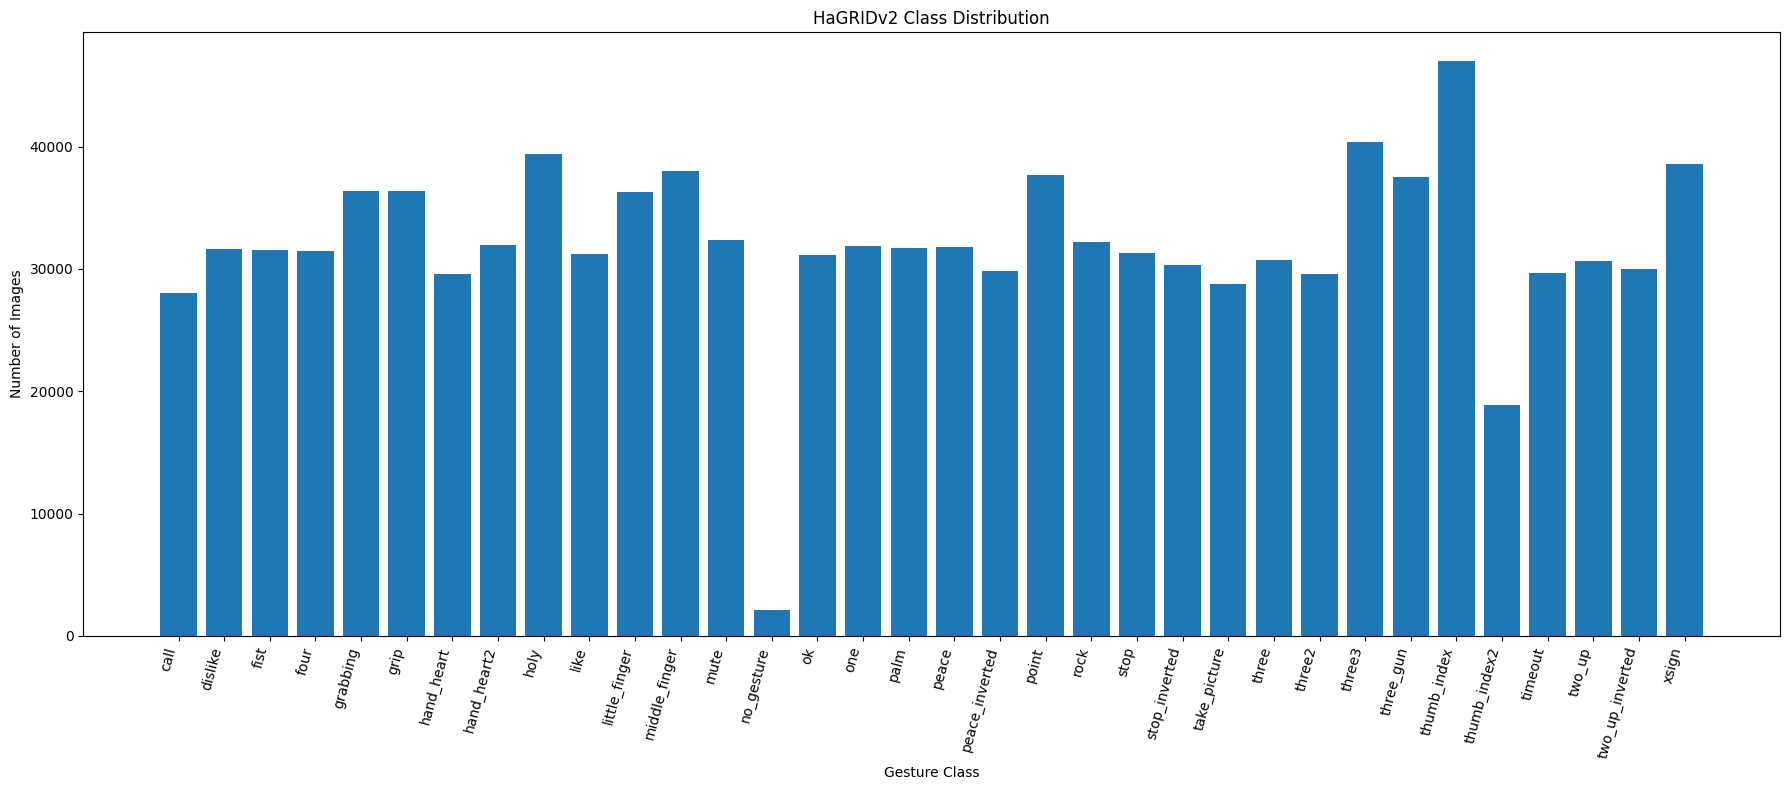

In [49]:
import matplotlib.pyplot as plt

# ============================================================
# BAR CHART
# ============================================================

plt.figure(figsize=(18, 8))

plt.bar(
    counts_df["Class"],
    counts_df["Total_count"]
)

plt.xlabel("Gesture Class")
plt.ylabel("Number of Images")
plt.title(
    "HaGRIDv2 Class Distribution"
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()

plt.show()

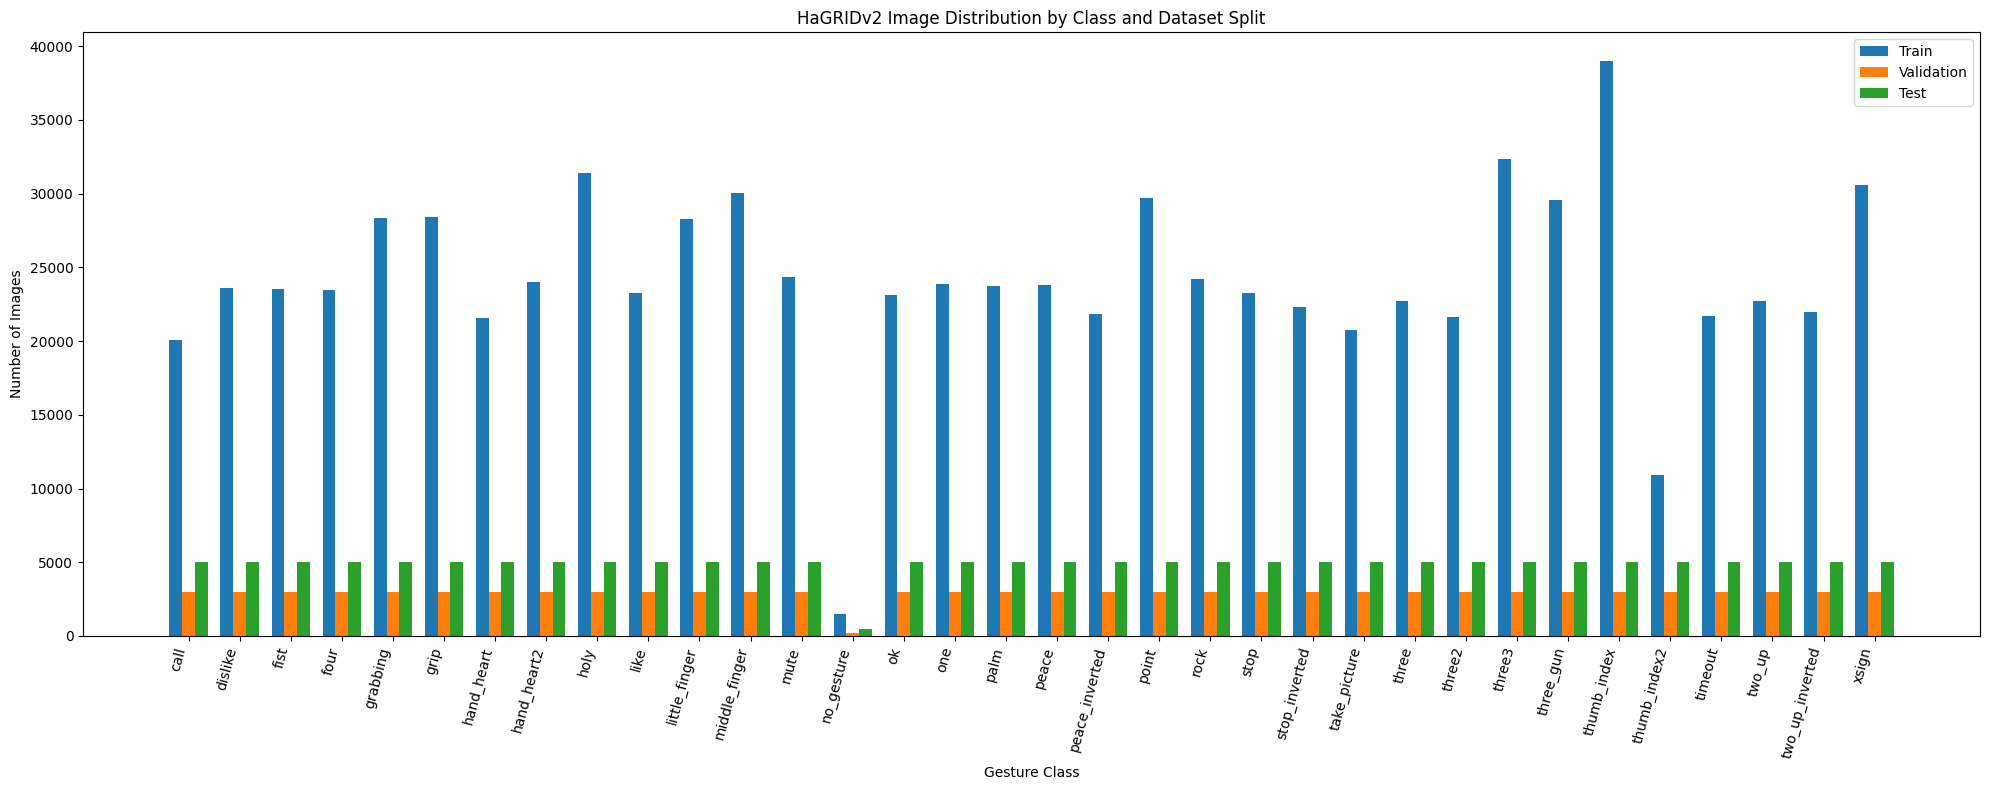

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TRAIN / VALIDATION / TEST DISTRIBUTION
# ============================================================

x = np.arange(len(counts_df))
width = 0.25

plt.figure(figsize=(20, 8))

plt.bar(
    x - width,
    counts_df["Train_count"],
    width,
    label="Train"
)

plt.bar(
    x,
    counts_df["Validation_count"],
    width,
    label="Validation"
)

plt.bar(
    x + width,
    counts_df["Test_count"],
    width,
    label="Test"
)

plt.xlabel("Gesture Class")
plt.ylabel("Number of Images")

plt.title(
    "HaGRIDv2 Image Distribution by Class and Dataset Split"
)

plt.xticks(
    x,
    counts_df["Class"],
    rotation=75,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.show()